# 🍽️ Zomato Bangalore Restaurant Data Science Project
## Alfido Tech Internship Submission

### End-to-End Data Science Workflow

**Business Understanding → Data Validation → Cleaning → EDA → KPIs → Feature Engineering → Classification → Regression → Hyperparameter Tuning → Clustering → Dimensionality Reduction → Business Insights → Recommendations**

---

### Project Goal

This project analyzes Zomato restaurant data for Bangalore to understand restaurant-market patterns and customer behavior, and to build machine-learning models for:

1. **Classification:** Predict whether a restaurant belongs to the expensive category.
2. **Regression:** Predict restaurant rating.
3. **Clustering:** Segment restaurants into meaningful groups.

The notebook also includes business KPIs, visual analysis, model evaluation, feature importance, recommendations.

# Table of Contents

1. Business Problem & Objectives  
2. Import Libraries  
3. Load Dataset  
4. Data Understanding  
5. Data Quality Audit  
6. Data Cleaning & Preprocessing  
7. KPI Analysis  
8. Exploratory Data Analysis  
   - Univariate Analysis  
   - Bivariate Analysis  
   - Multivariate Analysis  
   - Outlier Analysis  
   - Correlation Analysis  
9. Feature Engineering  
10. Classification: Expensive vs Not Expensive  
11. Classification Model Comparison  
12. Classification Hyperparameter Tuning  
13. Regression: Rating Prediction  
14. Regression Model Comparison  
15. Regression Hyperparameter Tuning  
16. Feature Importance  
17. Clustering & Restaurant Segmentation  
18. Elbow Method & Silhouette Score  
19. PCA Visualization  
20. t-SNE Visualization  
21. Cluster Profiling  
22. Final Insights  
23. Business Recommendations  
26. Conclusion


# 1. Business Problem & Objectives

## Problem Statement

The Bangalore restaurant market is highly competitive. Restaurant owners and food platforms need to understand customer preferences, restaurant concentration, cuisine demand, pricing, ratings, online ordering, table booking, and customer engagement.

## Main Objectives

- Clean and validate the raw restaurant data.
- Identify popular locations, restaurant types, and cuisines.
- Analyze pricing, ratings, votes, online ordering, and booking behavior.
- Build meaningful KPIs.
- Create a binary feature to classify restaurants as expensive or not expensive.
- Compare multiple classification algorithms.
- Predict restaurant ratings using regression models.
- Compare regression algorithms using proper metrics and cross-validation.
- Segment restaurants using unsupervised learning.
- Evaluate cluster quality using the elbow method and silhouette score.
- Visualize clusters using PCA and t-SNE.
- Translate technical results into actionable business recommendations.

# 2. Import Required Libraries


In [3]:
import warnings
warnings.filterwarnings("ignore")

import random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MaxAbsScaler,
    RobustScaler
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Regression models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Load Dataset

The first step is to load the raw data and inspect its structure.

In [4]:
DATA_PATH = "zomato.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
print("Raw dataset shape:", df_raw.shape)
print("\nColumns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i}. {col}")

Raw dataset shape: (56252, 13)

Columns:
1. address
2. name
3. online_order
4. book_table
5. rate
6. votes
7. phone
8. location
9. rest_type
10. dish_liked
11. cuisines
12. approx_cost(for two people)
13. listed_in(type)


# 4. Data Understanding

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   address                      56235 non-null  str  
 1   name                         56236 non-null  str  
 2   online_order                 56233 non-null  str  
 3   book_table                   56194 non-null  str  
 4   rate                         48414 non-null  str  
 5   votes                        56174 non-null  str  
 6   phone                        54956 non-null  str  
 7   location                     56126 non-null  str  
 8   rest_type                    55914 non-null  str  
 9   dish_liked                   28027 non-null  str  
 10  cuisines                     56049 non-null  str  
 11  approx_cost(for two people)  55731 non-null  str  
 12  listed_in(type)              51642 non-null  str  
dtypes: str(13)
memory usage: 5.6 MB


In [6]:
display(df_raw.describe(include='all').T)

,count,unique,top,freq
address,56235,13397,('Rated 4.0',942
name,56236,11914,('Rated 4.0',300
online_order,56233,2639,Yes,30444
book_table,56194,2902,No,45268
rate,48414,2877,NEW,2208
votes,56174,5195,0,10027
phone,54956,17712,('Rated 4.0',412
location,56126,2920,BTM,5125
rest_type,55914,2961,Quick Bites,19132
dish_liked,28027,8067,('Rated 4.0',407


In [8]:
schema = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Non-Null": df_raw.notna().sum().values,
    "Missing": df_raw.isna().sum().values,
    "Unique Values": [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
})

schema


,Column,Data Type,Non-Null,Missing,Unique Values
0,address,str,56235,17,13397
1,name,str,56236,16,11914
2,online_order,str,56233,19,2639
3,book_table,str,56194,58,2902
4,rate,str,48414,7838,2877
5,votes,str,56174,78,5195
6,phone,str,54956,1296,17712
7,location,str,56126,126,2920
8,rest_type,str,55914,338,2961
9,dish_liked,str,28027,28225,8067


## Feature Description

| Column | Meaning |
|---|---|
| address | Restaurant address |
| name | Restaurant name |
| online_order | Whether online ordering is available |
| book_table | Whether table booking is available |
| rate | Restaurant rating |
| votes | Customer vote count |
| phone | Contact number |
| location | Restaurant location |
| rest_type | Restaurant type |
| dish_liked | Popular dishes |
| cuisines | Cuisines offered |
| approx_cost(for two people) | Approximate cost for two |
| listed_in(type) | Zomato listing category |


# 5. Data Quality Audit

In [9]:
quality_report = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_%": (df_raw.isna().mean() * 100).round(2),
    "Unique_Count": df_raw.nunique(dropna=True)
}).sort_values("Missing_%", ascending=False)

quality_report

,Missing_Count,Missing_%,Unique_Count
dish_liked,28225,50.180,8067
rate,7838,13.930,2877
listed_in(type),4610,8.200,2783
phone,1296,2.300,17712
approx_cost(for two people),521,0.930,2879
rest_type,338,0.600,2961
cuisines,203,0.360,5553
location,126,0.220,2920
votes,78,0.140,5195
book_table,58,0.100,2902


In [10]:
duplicate_rows = df_raw.duplicated().sum()
print("Exact duplicate rows:", duplicate_rows)
print("Duplicate percentage:", round(duplicate_rows / len(df_raw) * 100, 2), "%")

Exact duplicate rows: 15703
Duplicate percentage: 27.92 %


In [11]:
print("Unique values in online_order (sample):")
print(df_raw['online_order'].dropna().astype(str).value_counts().head(20))

print("\nUnique values in book_table (sample):")
print(df_raw['book_table'].dropna().astype(str).value_counts().head(20))

print("\nUnique values in listed_in(type):")
print(df_raw['listed_in(type)'].dropna().astype(str).value_counts().head(20))


Unique values in online_order (sample):
online_order
Yes                                                                                                                                                                                                                                                    30444
No                                                                                                                                                                                                                                                     21273
 ('Rated 4.0'                                                                                                                                                                                                                                            493
 ('Rated 5.0'                                                                                                                                                                               

### Data Quality Observation

The raw file may contain malformed rows where review-like text appears in columns such as `online_order`, `book_table`, or `listed_in(type)`.

Because these columns have a known valid domain, they are used to detect structurally invalid records before analysis.

# 6. Data Cleaning & Preprocessing

In [12]:
valid_listing_types = [
    "Buffet",
    "Cafes",
    "Delivery",
    "Desserts",
    "Dine-out",
    "Drinks & nightlife",
    "Pubs and bars"
]

df = df_raw[
    df_raw["online_order"].isin(["Yes", "No"]) &
    df_raw["book_table"].isin(["Yes", "No"]) &
    df_raw["listed_in(type)"].isin(valid_listing_types)
].copy()

print("Rows retained after structural validation:", len(df))
print("Rows removed as malformed:", len(df_raw) - len(df))

Rows retained after structural validation: 47356
Rows removed as malformed: 8896


In [13]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print("Duplicates removed:", before - after)
print("Rows after duplicate removal:", after)

Duplicates removed: 13696
Rows after duplicate removal: 33660


## 6.1 Clean Rating

In [14]:
df["rating"] = pd.to_numeric(
    df["rate"]
      .astype(str)
      .str.extract(r"(\d+(?:\.\d+)?)")[0],
    errors="coerce"
)

df.loc[~df["rating"].between(0, 5), "rating"] = np.nan

display(df["rating"].describe())

count   28,133.000
mean         3.679
std          0.422
min          2.000
25%          3.400
50%          3.700
75%          4.000
max          4.900
Name: rating, dtype: float64

## 6.2 Clean Votes

In [15]:
df["votes_num"] = pd.to_numeric(df["votes"], errors="coerce")
display(df["votes_num"].describe())

count   33,660.000
mean       222.616
std        559.166
min          0.000
25%          8.000
50%         44.000
75%        195.000
max     16,345.000
Name: votes_num, dtype: float64

## 6.3 Clean Approximate Cost

In [16]:
df["cost_for_two"] = pd.to_numeric(
    df["approx_cost(for two people)"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.extract(r"(\d+(?:\.\d+)?)")[0],
    errors="coerce"
)

display(df["cost_for_two"].describe())

count   33,454.000
mean       545.490
std        423.950
min         40.000
25%        300.000
50%        400.000
75%        650.000
max      6,000.000
Name: cost_for_two, dtype: float64

## 6.4 Missing Values After Cleaning

In [17]:
clean_missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_%": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_%", ascending=False)

clean_missing

,Missing_Count,Missing_%
dish_liked,17997,53.470
rating,5527,16.420
rate,4099,12.180
phone,686,2.040
approx_cost(for two people),206,0.610
cost_for_two,206,0.610
rest_type,148,0.440
cuisines,32,0.100
location,14,0.040
votes,0,0.000


### Missing-Value Strategy

- `rating`: Keep missing for general EDA; drop missing only when rating is the ML target.
- `votes_num`: Impute with the median inside ML pipelines.
- `cost_for_two`: Impute with the median inside ML pipelines.
- Categorical columns: Impute using most frequent value inside ML pipelines.
- `dish_liked`, `phone`, `address`: useful for reference, but not used as primary ML predictors because they are high-cardinality or not analytically necessary.

# 7. KPI Analysis

In [18]:
kpi_values = {
    "Clean Restaurant Listings": len(df),
    "Unique Restaurant Names": df["name"].nunique(),
    "Number of Locations": df["location"].nunique(),
    "Valid Rated Records": df["rating"].notna().sum(),
    "Average Rating": round(df["rating"].mean(), 2),
    "Median Rating": round(df["rating"].median(), 2),
    "Median Cost for Two": round(df["cost_for_two"].median(), 2),
    "Average Cost for Two": round(df["cost_for_two"].mean(), 2),
    "Average Votes": round(df["votes_num"].mean(), 2),
    "Median Votes": round(df["votes_num"].median(), 2),
    "Online Order %": round(df["online_order"].eq("Yes").mean() * 100, 2),
    "Table Booking %": round(df["book_table"].eq("Yes").mean() * 100, 2),
}

kpi_df = pd.DataFrame(
    {"KPI": kpi_values.keys(), "Value": kpi_values.values()}
)
kpi_df

,KPI,Value
0,Clean Restaurant Listings,"33,660.000"
1,Unique Restaurant Names,"8,641.000"
2,Number of Locations,93.000
3,Valid Rated Records,"28,133.000"
4,Average Rating,3.680
5,Median Rating,3.700
6,Median Cost for Two,400.000
7,Average Cost for Two,545.490
8,Average Votes,222.620
9,Median Votes,44.000


In [19]:
print("===== KPI SUMMARY =====")
for k, v in kpi_values.items():
    print(f"{k}: {v}")

===== KPI SUMMARY =====
Clean Restaurant Listings: 33660
Unique Restaurant Names: 8641
Number of Locations: 93
Valid Rated Records: 28133
Average Rating: 3.68
Median Rating: 3.7
Median Cost for Two: 400.0
Average Cost for Two: 545.49
Average Votes: 222.62
Median Votes: 44.0
Online Order %: 60.21
Table Booking %: 11.58


# 8. Exploratory Data Analysis (EDA)

## 8.1 Numerical Distributions

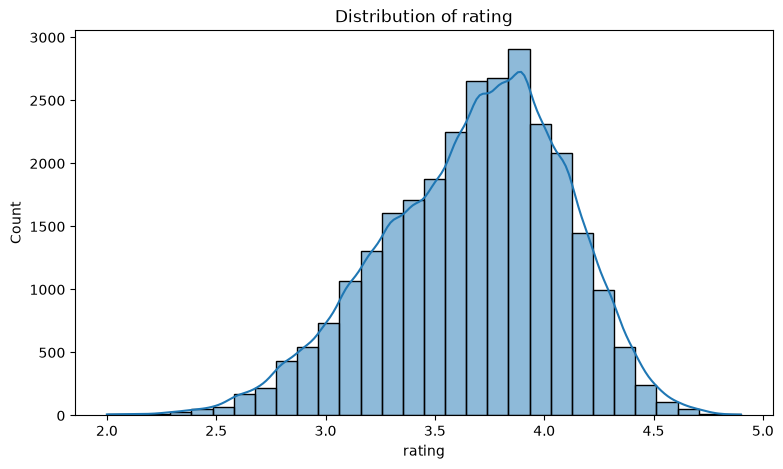

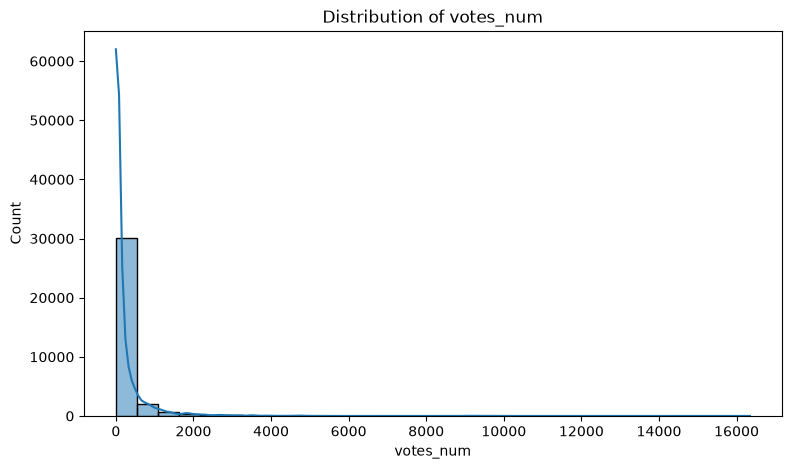

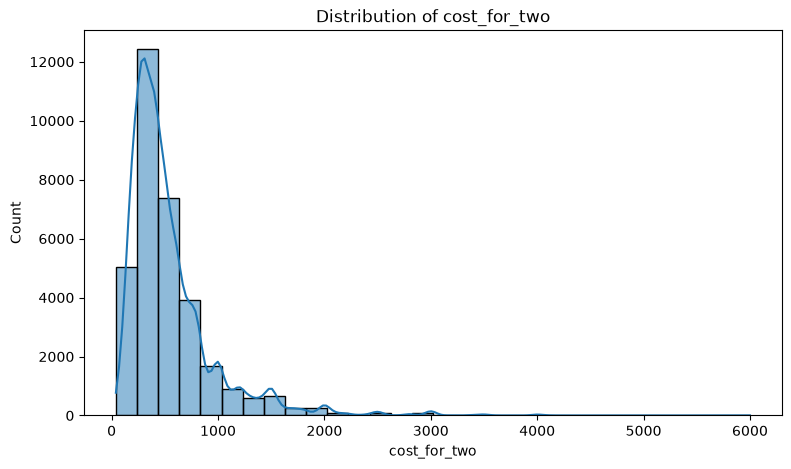

In [20]:
numerical_eda = ["rating", "votes_num", "cost_for_two"]

for col in numerical_eda:
    plt.figure(figsize=(9, 5))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Interpretation

- Rating distribution shows the most common quality band.
- Votes are usually right-skewed because a small number of highly popular restaurants receive very large engagement.
- Cost is also commonly right-skewed because premium restaurants form a smaller portion of the market.

## 8.2 Top 10 Locations

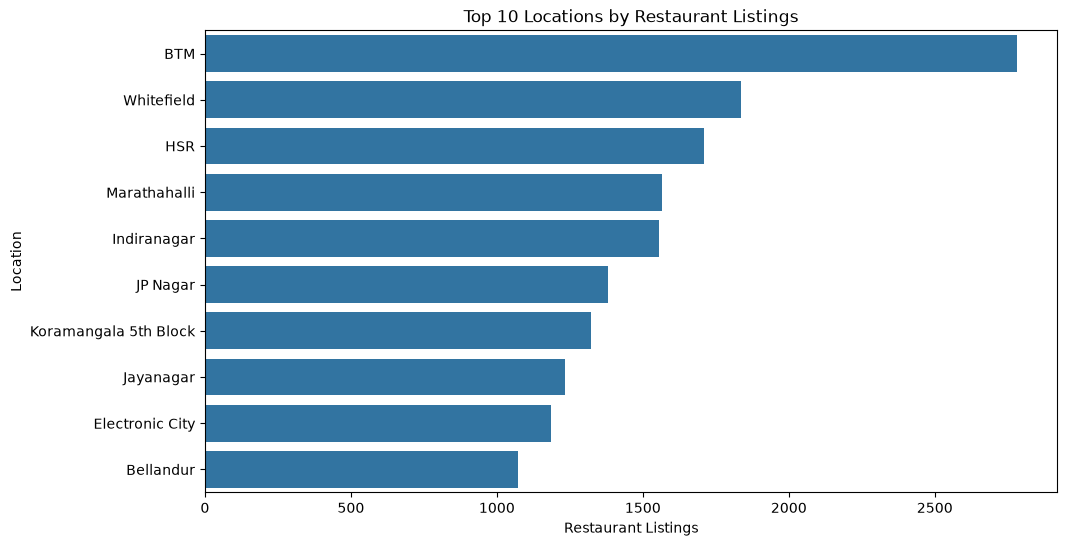

location
BTM                      2781
Whitefield               1837
HSR                      1710
Marathahalli             1565
Indiranagar              1557
JP Nagar                 1380
Koramangala 5th Block    1324
Jayanagar                1235
Electronic City          1184
Bellandur                1073
Name: count, dtype: int64

In [21]:
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Locations by Restaurant Listings")
plt.xlabel("Restaurant Listings")
plt.ylabel("Location")
plt.show()

top_locations

## 8.3 Top 10 Restaurant Types

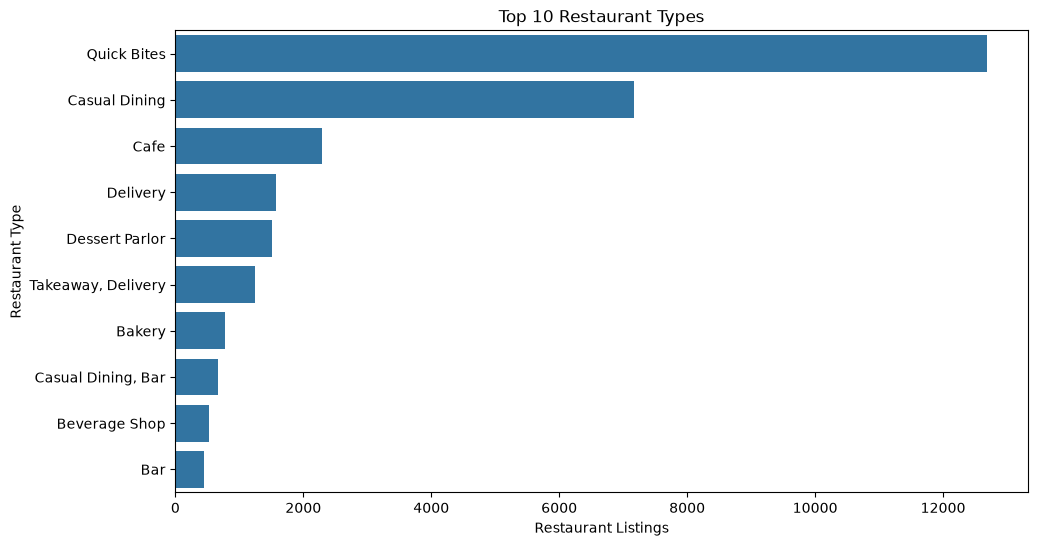

rest_type
Quick Bites           12691
Casual Dining          7170
Cafe                   2295
Delivery               1577
Dessert Parlor         1512
Takeaway, Delivery     1252
Bakery                  778
Casual Dining, Bar      674
Beverage Shop           526
Bar                     448
Name: count, dtype: int64

In [22]:
top_rest_types = df["rest_type"].value_counts().head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_rest_types.values, y=top_rest_types.index)
plt.title("Top 10 Restaurant Types")
plt.xlabel("Restaurant Listings")
plt.ylabel("Restaurant Type")
plt.show()

top_rest_types

## 8.4 Top 10 Cuisines

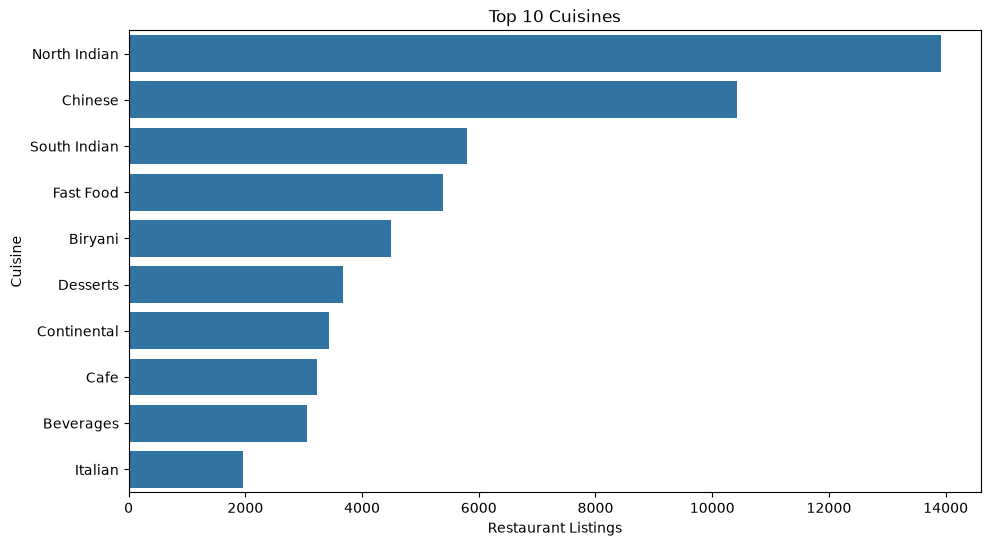

cuisines
North Indian    13912
Chinese         10418
South Indian     5801
Fast Food        5384
Biryani          4499
Desserts         3667
Continental      3428
Cafe             3232
Beverages        3065
Italian          1964
Name: count, dtype: int64

In [23]:
cuisine_exploded = (
    df["cuisines"]
      .dropna()
      .str.split(",")
      .explode()
      .str.strip()
)

top_cuisines = cuisine_exploded.value_counts().head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines")
plt.xlabel("Restaurant Listings")
plt.ylabel("Cuisine")
plt.show()

top_cuisines

## 8.5 Listing Type

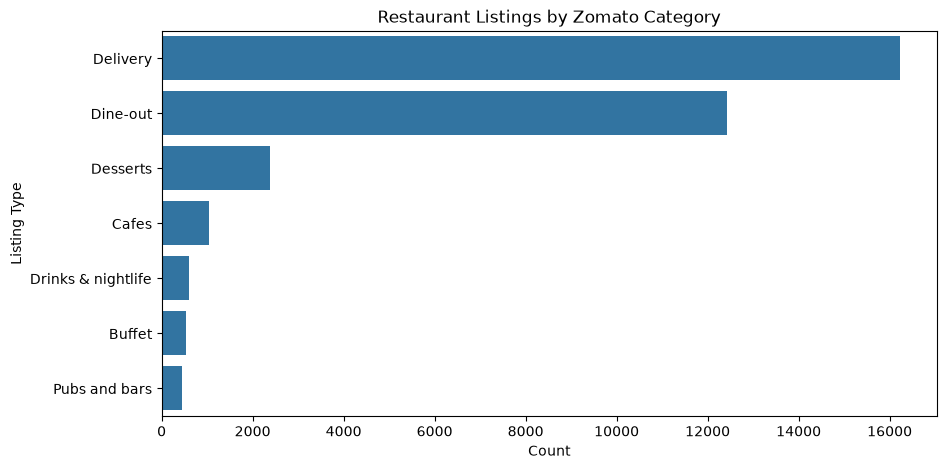

listed_in(type)
Delivery              16221
Dine-out              12434
Desserts               2383
Cafes                  1051
Drinks & nightlife      599
Buffet                  533
Pubs and bars           439
Name: count, dtype: int64

In [24]:
listing_counts = df["listed_in(type)"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=listing_counts.values, y=listing_counts.index)
plt.title("Restaurant Listings by Zomato Category")
plt.xlabel("Count")
plt.ylabel("Listing Type")
plt.show()

listing_counts

## 8.6 Online Ordering

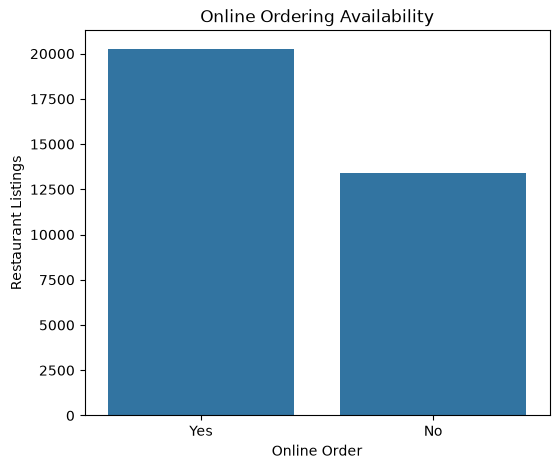

online_order
Yes    20267
No     13393
Name: count, dtype: int64

In [25]:
online_counts = df["online_order"].value_counts()

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="online_order")
plt.title("Online Ordering Availability")
plt.xlabel("Online Order")
plt.ylabel("Restaurant Listings")
plt.show()

online_counts

## 8.7 Table Booking

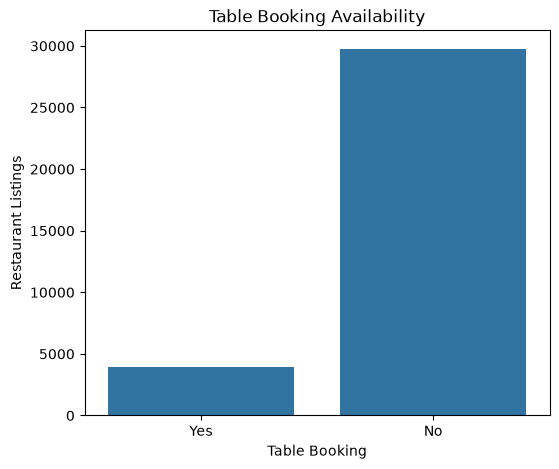

book_table
No     29762
Yes     3898
Name: count, dtype: int64

In [26]:
booking_counts = df["book_table"].value_counts()

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="book_table")
plt.title("Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Restaurant Listings")
plt.show()

booking_counts

## 8.8 Rating by Online Ordering

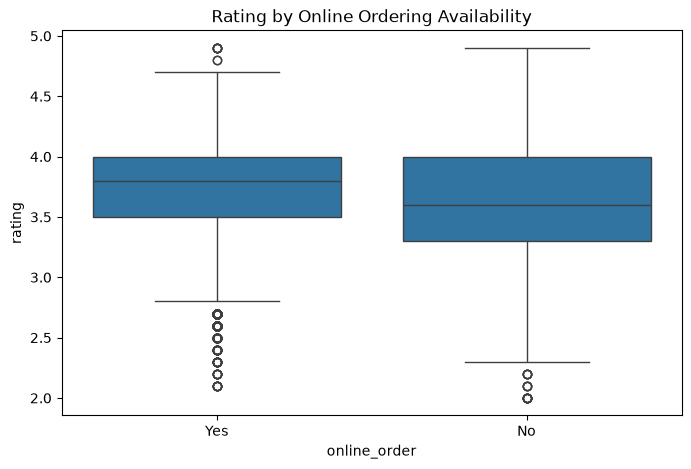

,count,mean,median
online_order,,,
No,9573,3.629,3.600
Yes,18560,3.705,3.800


In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="online_order", y="rating")
plt.title("Rating by Online Ordering Availability")
plt.show()

online_rating = df.groupby("online_order")["rating"].agg(["count", "mean", "median"]).round(3)
online_rating

## 8.9 Votes by Online Ordering

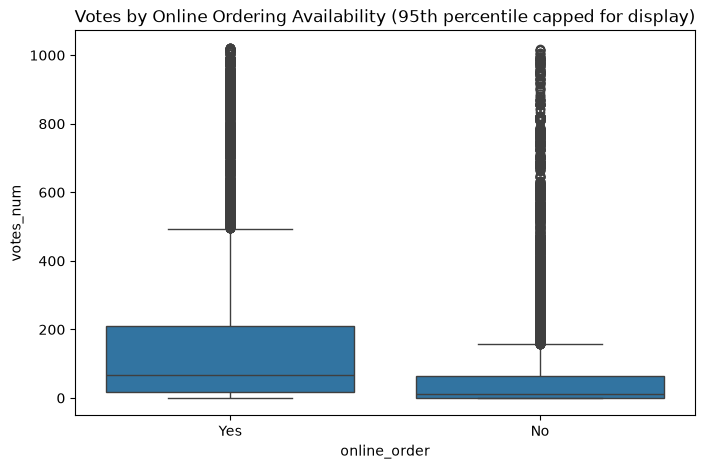

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df["votes_num"] <= df["votes_num"].quantile(0.95)],
            x="online_order", y="votes_num")
plt.title("Votes by Online Ordering Availability (95th percentile capped for display)")
plt.show()

## 8.10 Cost by Online Ordering

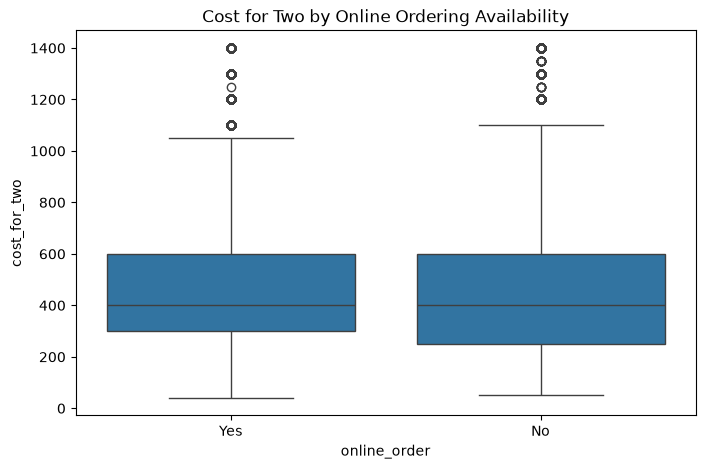

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df["cost_for_two"] <= df["cost_for_two"].quantile(0.95)],
            x="online_order", y="cost_for_two")
plt.title("Cost for Two by Online Ordering Availability")
plt.show()

## 8.11 Rating by Table Booking

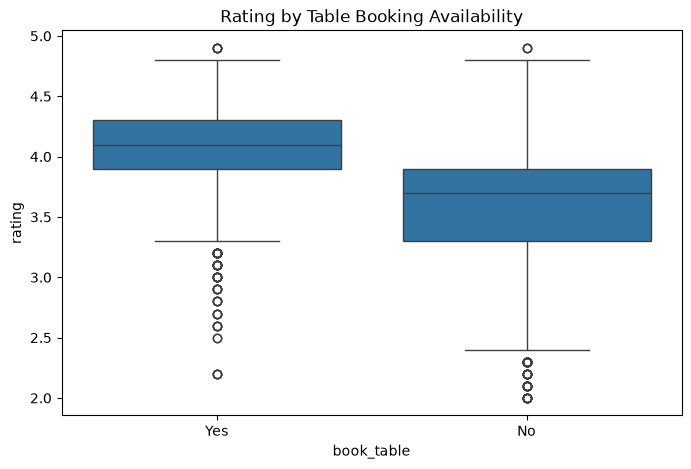

,count,mean,median
book_table,,,
No,24331,3.617,3.700
Yes,3802,4.078,4.100


In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="book_table", y="rating")
plt.title("Rating by Table Booking Availability")
plt.show()

booking_rating = df.groupby("book_table")["rating"].agg(["count", "mean", "median"]).round(3)
booking_rating

## 8.12 Cost vs Rating

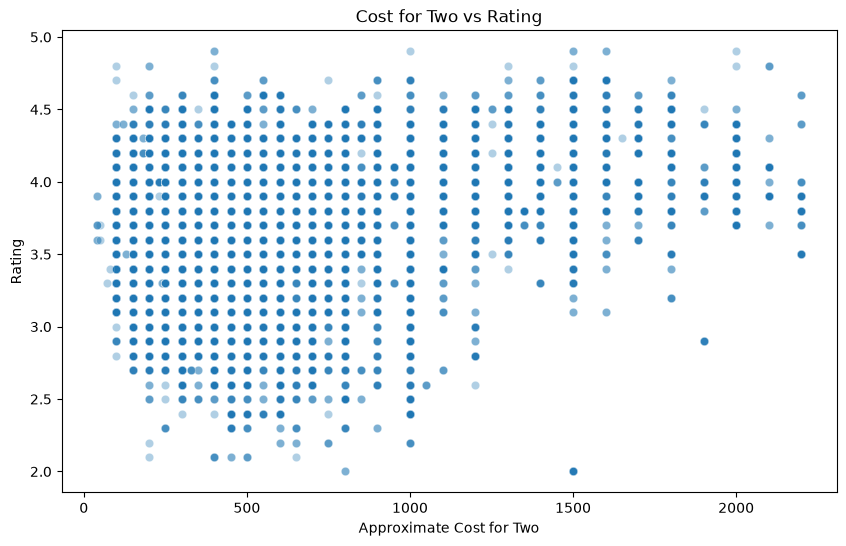

Correlation: 0.334


In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df[df["cost_for_two"] <= df["cost_for_two"].quantile(0.99)],
    x="cost_for_two",
    y="rating",
    alpha=0.35
)
plt.title("Cost for Two vs Rating")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Rating")
plt.show()

print("Correlation:", round(df[["cost_for_two", "rating"]].corr().iloc[0, 1], 3))

## 8.13 Votes vs Rating

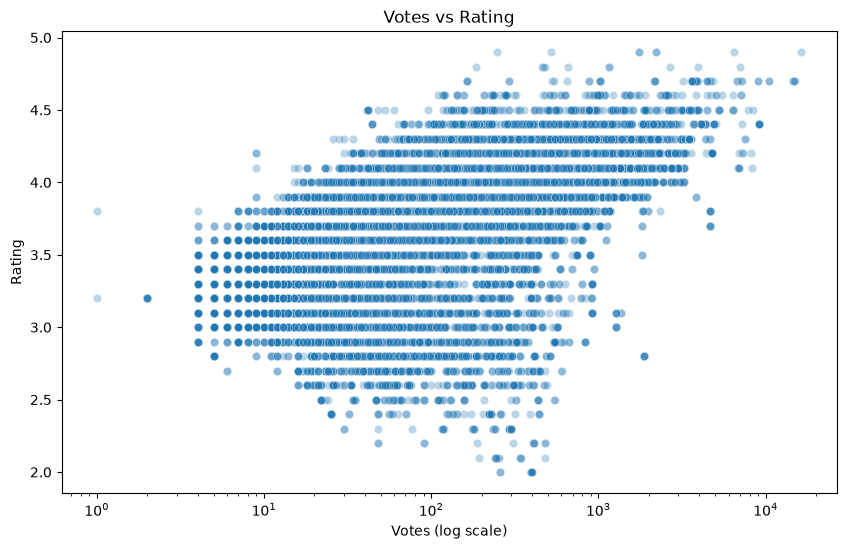

Correlation: 0.399


In [32]:
votes_plot = df[(df["votes_num"] > 0) & df["rating"].notna()].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=votes_plot, x="votes_num", y="rating", alpha=0.3)
plt.xscale("log")
plt.title("Votes vs Rating")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.show()

print("Correlation:", round(df[["votes_num", "rating"]].corr().iloc[0, 1], 3))

## 8.14 Pairplot of Numerical Features

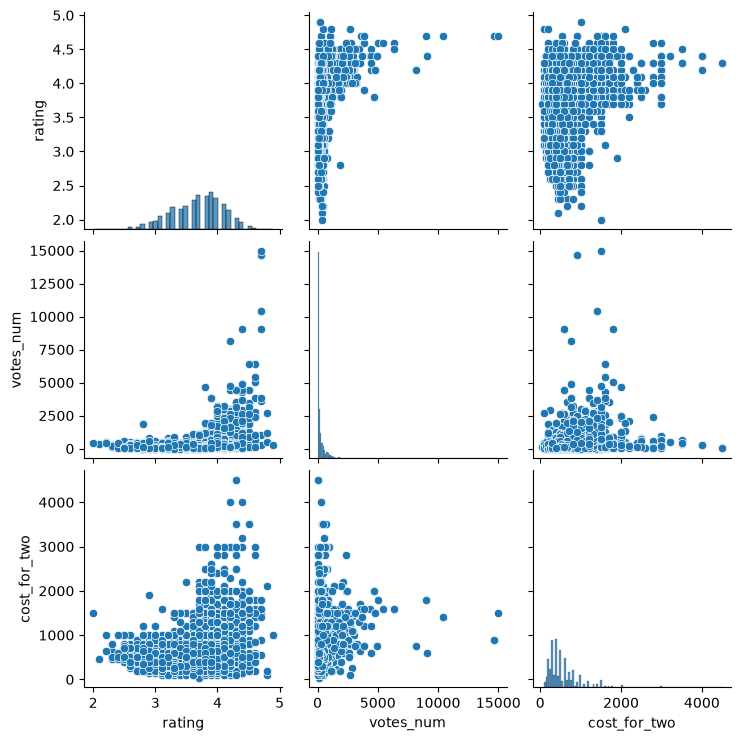

In [33]:
pair_sample = df[["rating", "votes_num", "cost_for_two"]].dropna()

if len(pair_sample) > 5000:
    pair_sample = pair_sample.sample(5000, random_state=42)

sns.pairplot(pair_sample)
plt.show()

## 8.15 Correlation Heatmap

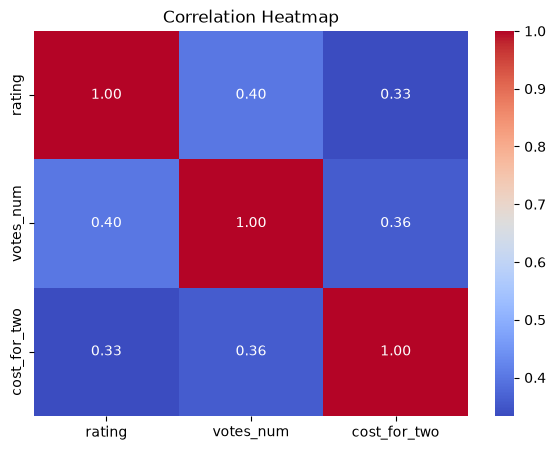

,rating,votes_num,cost_for_two
rating,1.000,0.399,0.334
votes_num,0.399,1.000,0.357
cost_for_two,0.334,0.357,1.000


In [34]:
corr = df[["rating", "votes_num", "cost_for_two"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

corr

## 8.16 Outlier Analysis

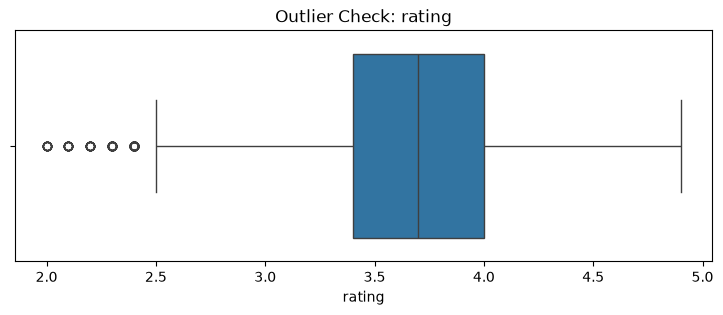

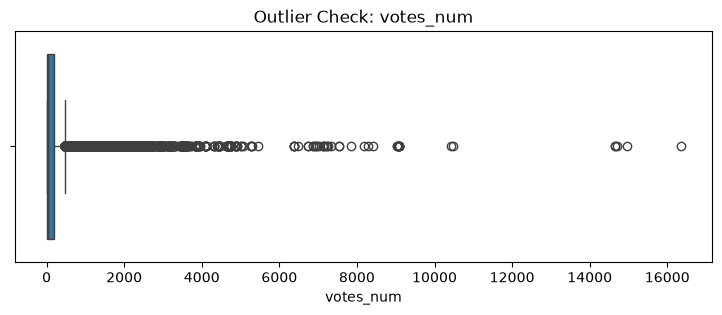

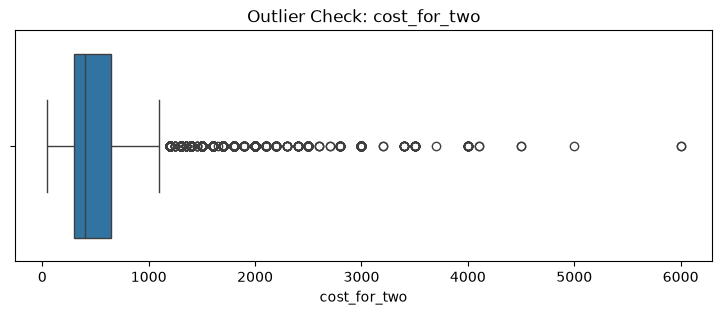

votes_num: IQR outliers = 4112
cost_for_two: IQR outliers = 2656


In [35]:
fig_data = df[["rating", "votes_num", "cost_for_two"]].copy()

for col in fig_data.columns:
    plt.figure(figsize=(9, 3))
    sns.boxplot(x=fig_data[col])
    plt.title(f"Outlier Check: {col}")
    plt.show()

for col in ["votes_num", "cost_for_two"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR outliers = {count}")

# 9. Feature Engineering

In [36]:
# Number of cuisines offered
df["cuisine_count"] = (
    df["cuisines"]
      .fillna("")
      .apply(lambda x: len([c for c in x.split(",") if c.strip()]) if x else 0)
)

# Binary service features
df["online_order_flag"] = df["online_order"].map({"Yes": 1, "No": 0})
df["book_table_flag"] = df["book_table"].map({"Yes": 1, "No": 0})

# Expensive restaurant target: above median cost
median_cost = df["cost_for_two"].median()

df["expensive"] = np.where(
    df["cost_for_two"].notna(),
    (df["cost_for_two"] > median_cost).astype(int),
    np.nan
)
# Rating band for EDA/dashboard
df["rating_band"] = pd.cut(
    df["rating"],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.01],
    labels=["Below 3.0", "3.0-3.4", "3.5-3.9", "4.0-4.4", "4.5-5.0"],
    right=False
)

# Cost category
df["cost_category"] = pd.cut(
    df["cost_for_two"],
    bins=[0, 300, 600, 1000, 2000, np.inf],
    labels=["₹300 or less", "₹301-600", "₹601-1000", "₹1001-2000", "Above ₹2000"]
)

df[[
    "cuisine_count",
    "online_order_flag",
    "book_table_flag",
    "expensive",
    "rating_band",
    "cost_category"
]].head()

,cuisine_count,online_order_flag,book_table_flag,expensive,rating_band,cost_category
0,3,1,1,1.000,4.0-4.4,₹601-1000
1,3,1,0,1.000,4.0-4.4,₹601-1000
2,3,1,0,1.000,3.5-3.9,₹601-1000
3,2,0,0,0.000,3.5-3.9,₹300 or less
4,2,0,0,1.000,3.5-3.9,₹301-600


In [37]:
print("Median cost threshold used for expensive classification:", median_cost)
print("\nExpensive target distribution:")
print(df["expensive"].value_counts(dropna=False))

Median cost threshold used for expensive classification: 400.0

Expensive target distribution:
expensive
0.000    17472
1.000    15982
NaN        206
Name: count, dtype: int64


# 10. Classification — Expensive vs Not Expensive

## Target Definition

- `0` = cost for two is less than or equal to the median.
- `1` = cost for two is greater than the median.

### Important Leakage Rule

The original cost column is **not used as a predictor**, because the `expensive` target is directly created from cost. Including it would make the classification task artificially easy and cause target leakage.

In [38]:
clf_df = df.dropna(subset=["expensive"]).copy()
clf_df["expensive"] = clf_df["expensive"].astype(int)

clf_features = [
    "online_order",
    "book_table",
    "rating",
    "votes_num",
    "location",
    "rest_type",
    "listed_in(type)",
    "cuisine_count"
]

X_clf = clf_df[clf_features]
y_clf = clf_df["expensive"]
print("Classification dataset shape:", X_clf.shape)
print("\nClass distribution:")
print(y_clf.value_counts())
print("\nClass percentage:")
print((y_clf.value_counts(normalize=True) * 100).round(2))

Classification dataset shape: (33454, 8)

Class distribution:
expensive
0    17472
1    15982
Name: count, dtype: int64

Class percentage:
expensive
0   52.230
1   47.770
Name: proportion, dtype: float64


## 10.1 Train-Test Split

In [39]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Train:", Xc_train.shape)
print("Test :", Xc_test.shape)

Train: (26763, 8)
Test : (6691, 8)


## 10.2 Classification Preprocessing

In [40]:
clf_categorical = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "listed_in(type)"
]

clf_numerical = [
    "rating",
    "votes_num",
    "cuisine_count"
]

clf_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
])

clf_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MaxAbsScaler())
])

clf_preprocessor = ColumnTransformer([
    ("cat", clf_cat_pipe, clf_categorical),
    ("num", clf_num_pipe, clf_numerical)
])

## 10.3 Classification Models

In [41]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=42
    )
}

## 10.4 Train and Evaluate All Classification Models

In [42]:
clf_results = []
clf_fitted_models = {}
clf_predictions = {}

for name, model in classification_models.items():
    pipe = Pipeline([
        ("preprocessor", clf_preprocessor),
        ("model", model)
    ])

    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)

    if hasattr(pipe, "predict_proba"):
        prob = pipe.predict_proba(Xc_test)[:, 1]
        auc = roc_auc_score(yc_test, prob)
    else:
        auc = np.nan

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred, zero_division=0),
        "Recall": recall_score(yc_test, pred, zero_division=0),
        "F1 Score": f1_score(yc_test, pred, zero_division=0),
        "ROC-AUC": auc
    })

    clf_fitted_models[name] = pipe
    clf_predictions[name] = pred

clf_results_df = pd.DataFrame(clf_results).sort_values("F1 Score", ascending=False)
clf_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.928,0.950,0.897,0.923,0.972
1,Decision Tree,0.857,0.912,0.775,0.838,0.914
0,Logistic Regression,0.853,0.903,0.776,0.834,0.919



## 10.5 Classification Model Comparison


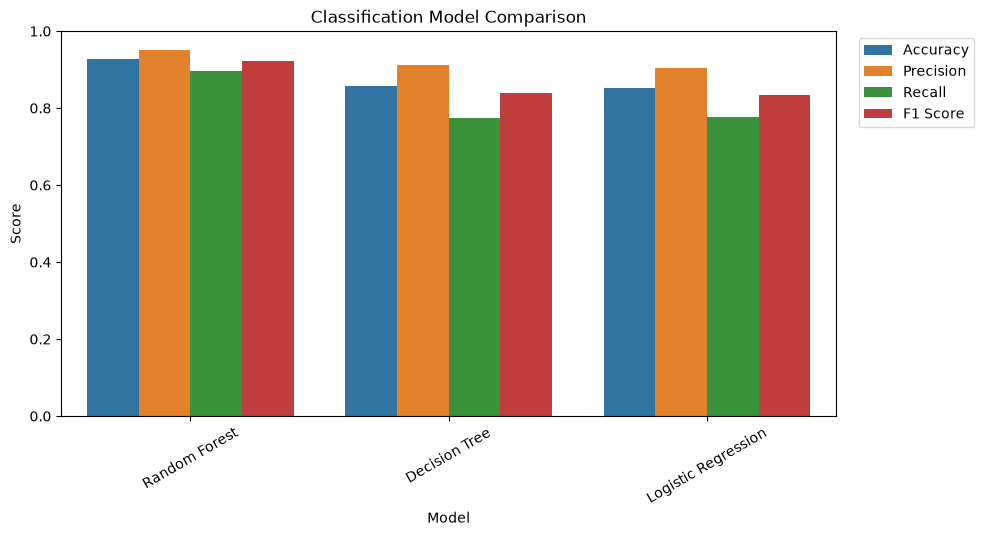

In [43]:
plt.figure(figsize=(10, 5))
plot_df = clf_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.title("Classification Model Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 10.6 Best Classification Model

In [44]:
best_clf_name = clf_results_df.iloc[0]["Model"]
best_clf = clf_fitted_models[best_clf_name]
best_clf_pred = clf_predictions[best_clf_name]

print("Best classification model by F1 Score:", best_clf_name)
print("\nClassification Report:\n")
print(classification_report(yc_test, best_clf_pred))

Best classification model by F1 Score: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      3495
           1       0.95      0.90      0.92      3196

    accuracy                           0.93      6691
   macro avg       0.93      0.93      0.93      6691
weighted avg       0.93      0.93      0.93      6691



## 10.7 Confusion Matrix

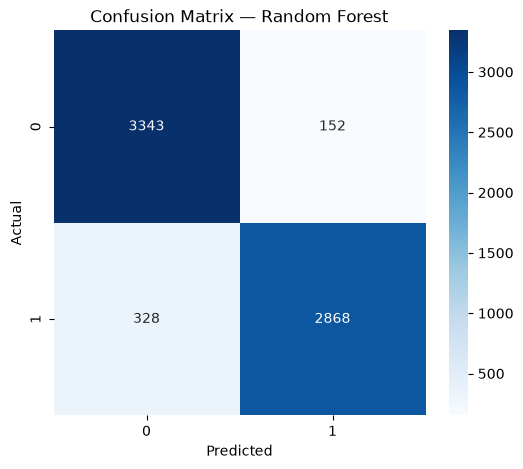

In [45]:
cm = confusion_matrix(yc_test, best_clf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10.8 ROC Curve

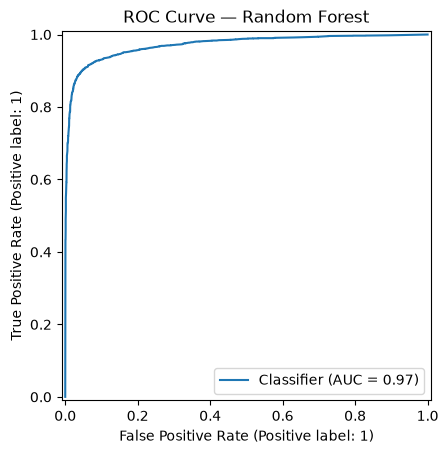

In [46]:
if hasattr(best_clf, "predict_proba"):
    best_prob = best_clf.predict_proba(Xc_test)[:, 1]
    RocCurveDisplay.from_predictions(yc_test, best_prob)
    plt.title(f"ROC Curve — {best_clf_name}")
    plt.show()

## 10.9 Classification Cross-Validation

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_clf_cv = cross_val_score(
    best_clf,
    X_clf,
    y_clf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("5-Fold F1 Scores:", np.round(best_clf_cv, 4))
print("Mean F1:", round(best_clf_cv.mean(), 4))
print("Std F1 :", round(best_clf_cv.std(), 4))

5-Fold F1 Scores: [0.9165 0.9222 0.9179 0.9152 0.9188]
Mean F1: 0.9181
Std F1 : 0.0024


# 11. Classification Hyperparameter Tuning — Random Forest

In [48]:
rf_clf_pipeline = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_clf_params = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_clf_search = RandomizedSearchCV(
    rf_clf_pipeline,
    param_distributions=rf_clf_params,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_clf_search.fit(Xc_train, yc_train)

print("Best parameters:")
print(rf_clf_search.best_params_)
print("Best CV F1:", round(rf_clf_search.best_score_, 4))

Best parameters:
{'model__n_estimators': 350, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
Best CV F1: 0.8939


In [49]:
tuned_clf_pred = rf_clf_search.predict(Xc_test)

print("Tuned Random Forest Test Metrics")
print("Accuracy :", round(accuracy_score(yc_test, tuned_clf_pred), 4))
print("Precision:", round(precision_score(yc_test, tuned_clf_pred), 4))
print("Recall   :", round(recall_score(yc_test, tuned_clf_pred), 4))
print("F1 Score :", round(f1_score(yc_test, tuned_clf_pred), 4))

Tuned Random Forest Test Metrics
Accuracy : 0.9274
Precision: 0.9478
Recall   : 0.8974
F1 Score : 0.9219


# 12. Regression — Restaurant Rating Prediction

## Target

`rating`

### Predictor Strategy

The regression model uses restaurant services, votes, cost, location, restaurant type, listing category, and cuisine count.

Rows with missing target ratings are removed. Predictor missing values are handled inside the preprocessing pipeline.

In [50]:
reg_df = df.dropna(subset=["rating"]).copy()

reg_features = [
    "online_order",
    "book_table",
    "votes_num",
    "cost_for_two",
    "location",
    "rest_type",
    "listed_in(type)",
    "cuisine_count"
]

X_reg = reg_df[reg_features]
y_reg = reg_df["rating"]

print("Regression dataset shape:", X_reg.shape)

Regression dataset shape: (28133, 8)


## 12.1 Train-Test Split

In [51]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Train:", Xr_train.shape)
print("Test :", Xr_test.shape)

Train: (22506, 8)
Test : (5627, 8)


## 12.2 Regression Preprocessing

In [52]:
reg_categorical = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "listed_in(type)"
]

reg_numerical = [
    "votes_num",
    "cost_for_two",
    "cuisine_count"
]

reg_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
])

reg_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MaxAbsScaler())
])

reg_preprocessor = ColumnTransformer([
    ("cat", reg_cat_pipe, reg_categorical),
    ("num", reg_num_pipe, reg_numerical)
])

## 12.3 Regression Models

In [53]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=5000),
    "ElasticNet Regression": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=5,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1
    )
}

## 12.4 Train and Evaluate All Regression Models

In [54]:
reg_results = []
reg_fitted_models = {}
reg_predictions = {}

for name, model in regression_models.items():
    pipe = Pipeline([
        ("preprocessor", reg_preprocessor),
        ("model", model)
    ])

    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)

    mae = mean_absolute_error(yr_test, pred)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    r2 = r2_score(yr_test, pred)

    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    reg_fitted_models[name] = pipe
    reg_predictions[name] = pred

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
reg_results_df.round(4)

,Model,MAE,RMSE,R2 Score
7,Extra Trees,0.065,0.161,0.858
5,Random Forest,0.164,0.246,0.669
4,Decision Tree,0.204,0.298,0.515
6,Gradient Boosting,0.223,0.314,0.460
1,Ridge Regression,0.269,0.349,0.333
0,Linear Regression,0.269,0.349,0.333
3,ElasticNet Regression,0.276,0.355,0.309
2,Lasso Regression,0.278,0.357,0.301


## 12.5 Regression Model Comparison

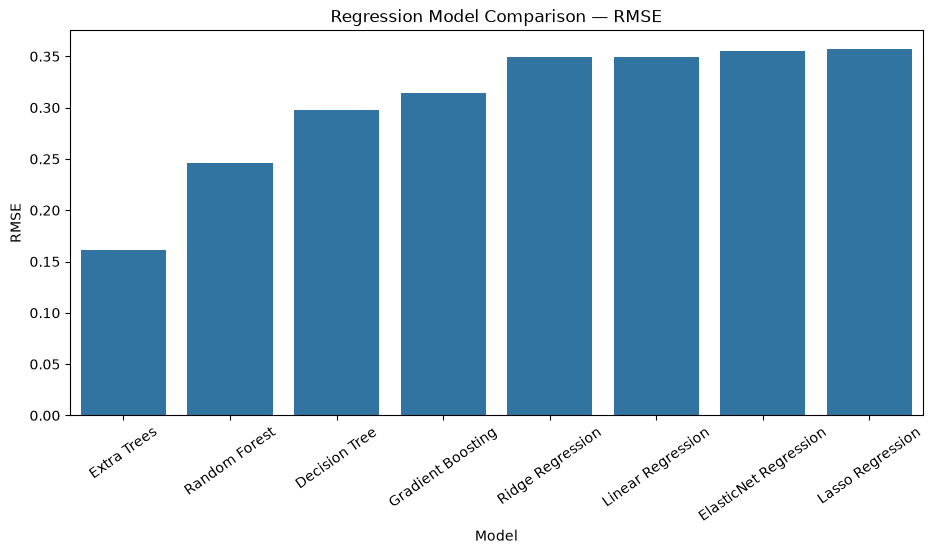

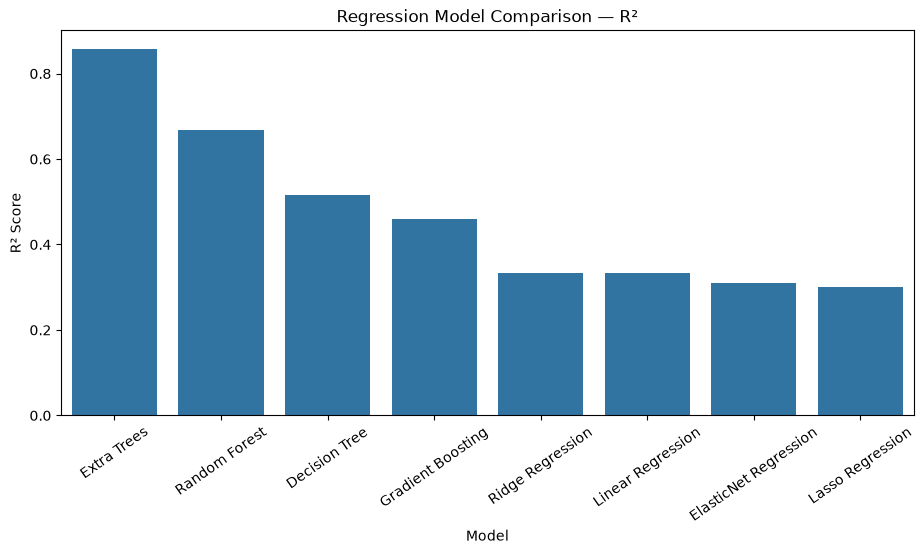

In [55]:
plt.figure(figsize=(11, 5))
sns.barplot(data=reg_results_df, x="Model", y="RMSE")
plt.xticks(rotation=35)
plt.title("Regression Model Comparison — RMSE")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=reg_results_df, x="Model", y="R2 Score")
plt.xticks(rotation=35)
plt.title("Regression Model Comparison — R²")
plt.ylabel("R² Score")
plt.show()

## 12.6 Best Regression Model

In [56]:
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg = reg_fitted_models[best_reg_name]
best_reg_pred = reg_predictions[best_reg_name]

print("Best regression model by RMSE:", best_reg_name)
print("MAE :", round(mean_absolute_error(yr_test, best_reg_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_test, best_reg_pred)), 4))
print("R²  :", round(r2_score(yr_test, best_reg_pred), 4))

Best regression model by RMSE: Extra Trees
MAE : 0.0648
RMSE: 0.1611
R²  : 0.8581


## 12.7 Actual vs Predicted Rating

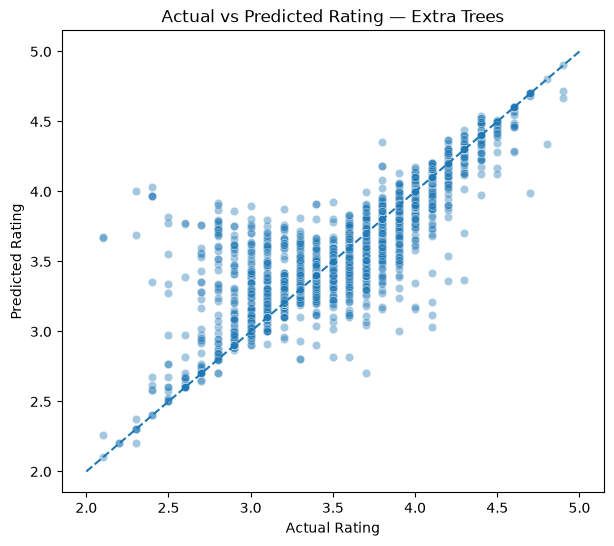

In [57]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=yr_test, y=best_reg_pred, alpha=0.4)
plt.plot([2, 5], [2, 5], linestyle="--")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(f"Actual vs Predicted Rating — {best_reg_name}")
plt.show()

## 12.8 Residual Analysis

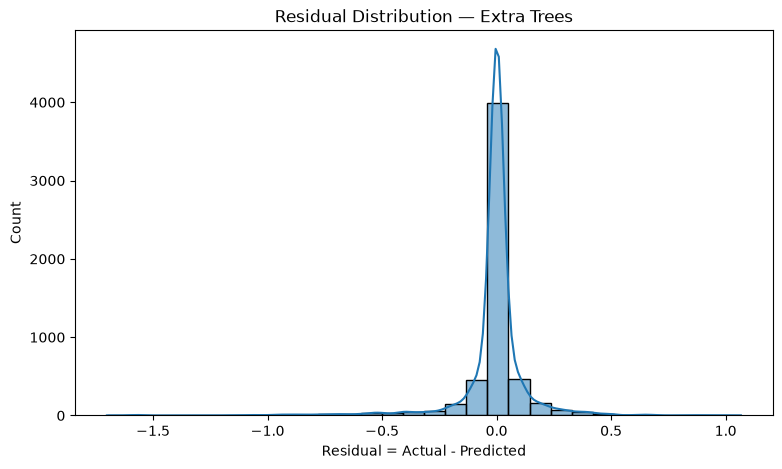

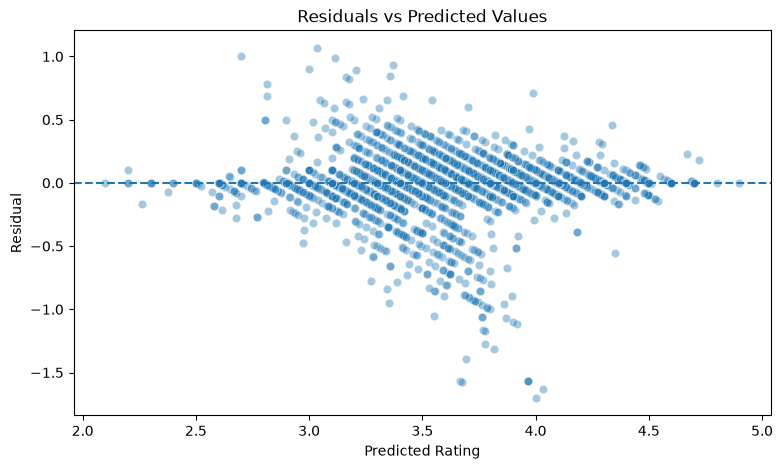

In [58]:
residuals = yr_test - best_reg_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title(f"Residual Distribution — {best_reg_name}")
plt.xlabel("Residual = Actual - Predicted")
plt.show()

plt.figure(figsize=(9, 5))
sns.scatterplot(x=best_reg_pred, y=residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

## 12.9 Regression Cross-Validation

In [59]:
reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)

best_reg_cv = cross_val_score(
    best_reg,
    X_reg,
    y_reg,
    cv=reg_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

best_reg_cv_rmse = -best_reg_cv

print("5-Fold RMSE:", np.round(best_reg_cv_rmse, 4))
print("Mean RMSE:", round(best_reg_cv_rmse.mean(), 4))
print("Std RMSE :", round(best_reg_cv_rmse.std(), 4))

5-Fold RMSE: [0.1617 0.1492 0.1474 0.1494 0.15  ]
Mean RMSE: 0.1515
Std RMSE : 0.0052


# 13. Regression Hyperparameter Tuning — Random Forest

In [60]:
rf_reg_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_reg_params = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [10, 18, 25, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

rf_reg_search = RandomizedSearchCV(
    rf_reg_pipeline,
    param_distributions=rf_reg_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_reg_search.fit(Xr_train, yr_train)

print("Best parameters:")
print(rf_reg_search.best_params_)
print("Best CV RMSE:", round(-rf_reg_search.best_score_, 4))

Best parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 25}
Best CV RMSE: 0.2265


In [61]:
tuned_reg_pred = rf_reg_search.predict(Xr_test)

print("Tuned Random Forest Test Metrics")
print("MAE :", round(mean_absolute_error(yr_test, tuned_reg_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_test, tuned_reg_pred)), 4))
print("R²  :", round(r2_score(yr_test, tuned_reg_pred), 4))

Tuned Random Forest Test Metrics
MAE : 0.133
RMSE: 0.2126
R²  : 0.7527


# 14. Feature Importance

,Feature,Importance
163,num__votes_num,0.182
107,cat__rest_type_Casual Dining,0.126
143,cat__rest_type_Quick Bites,0.116
162,num__rating,0.104
164,num__cuisine_count,0.065
3,cat__book_table_Yes,0.036
2,cat__book_table_No,0.029
101,cat__rest_type_Cafe,0.022
116,cat__rest_type_Dessert Parlor,0.012
159,cat__listed_in(type)_Dine-out,0.008


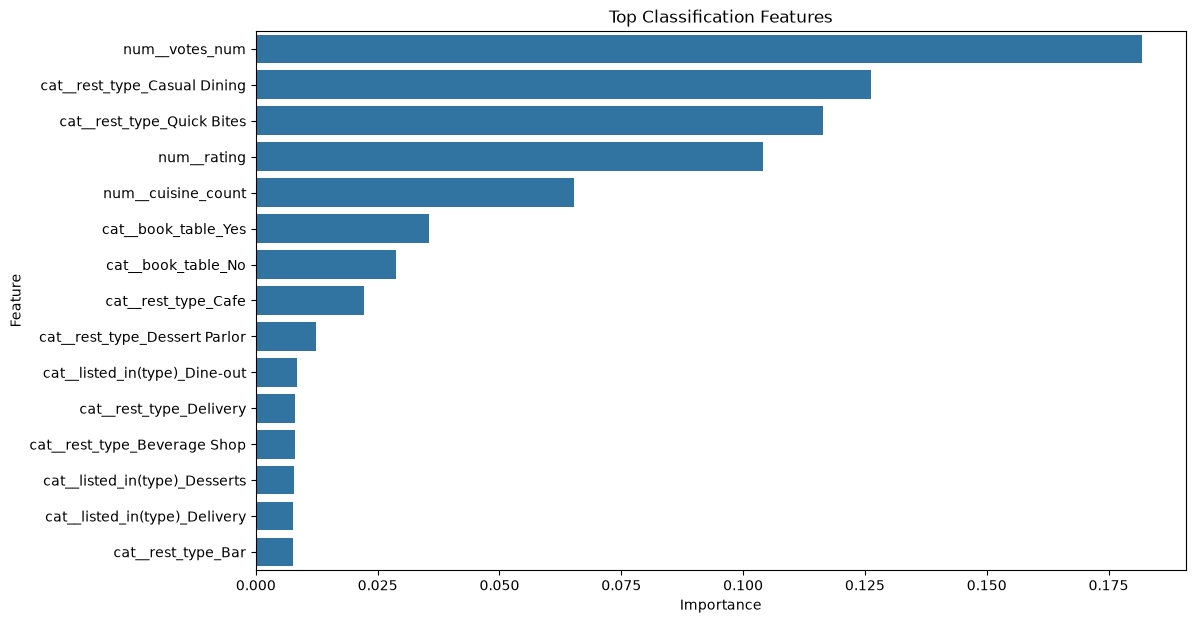

In [64]:
rf_clf_best = rf_clf_search.best_estimator_

clf_feature_names = (
    rf_clf_best
      .named_steps["preprocessor"]
      .get_feature_names_out()
)

clf_importances = (
    rf_clf_best
      .named_steps["model"]
      .feature_importances_
)

clf_importance_df = pd.DataFrame({
    "Feature": clf_feature_names,
    "Importance": clf_importances
}).sort_values("Importance", ascending=False)

display(clf_importance_df.head(20))

plt.figure(figsize=(12, 7))

sns.barplot(
    data=clf_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Classification Features")
plt.show()

## 14.2 Regression Feature Importance — Random Forest

,Feature,Importance
165,num__votes_num,0.533
166,num__cost_for_two,0.085
167,num__cuisine_count,0.040
118,cat__rest_type_Dessert Parlor,0.016
109,cat__rest_type_Casual Dining,0.013
146,cat__rest_type_Quick Bites,0.013
59,cat__location_Marathahalli,0.010
2,cat__book_table_No,0.010
3,cat__book_table_Yes,0.010
103,cat__rest_type_Cafe,0.009


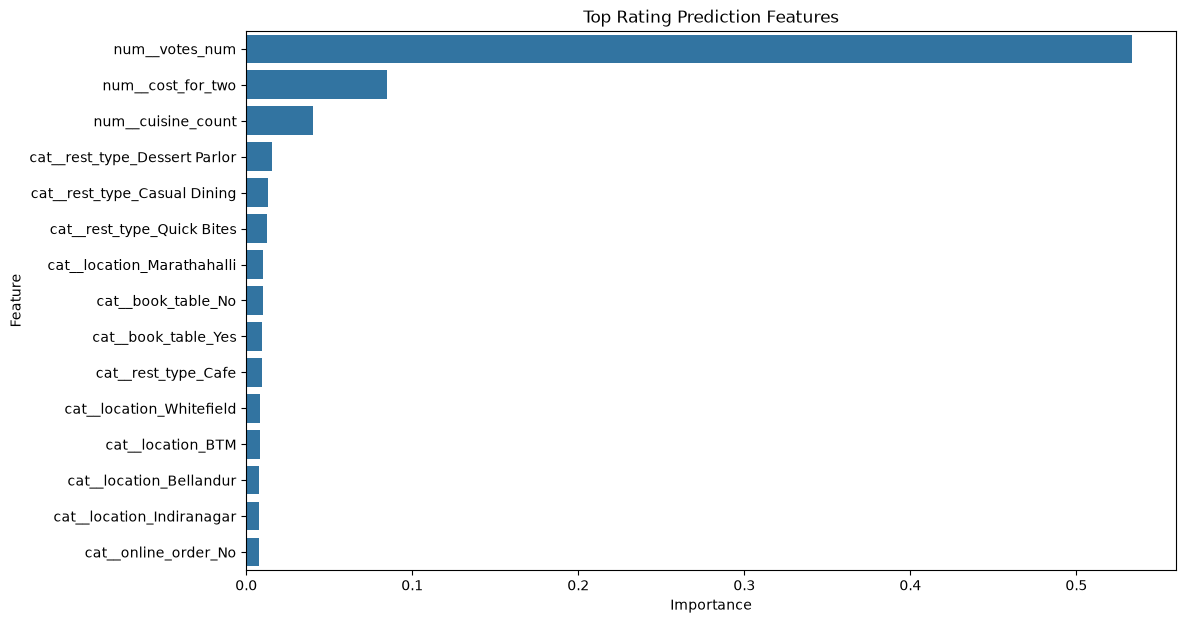

In [65]:
rf_reg_best = rf_reg_search.best_estimator_

reg_feature_names = (
    rf_reg_best
      .named_steps["preprocessor"]
      .get_feature_names_out()
)

reg_importances = (
    rf_reg_best
      .named_steps["model"]
      .feature_importances_
)

reg_importance_df = pd.DataFrame({
    "Feature": reg_feature_names,
    "Importance": reg_importances
}).sort_values("Importance", ascending=False)

display(reg_importance_df.head(20))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=reg_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top Rating Prediction Features")
plt.show()

### Interpretation

Feature importance tells us which variables the model uses most strongly for prediction.

It does **not** prove causation. A feature may be predictive because it is associated with the target, not because it directly causes the outcome.

# 15. Clustering — Restaurant Segmentation

For clustering, we create a compact numerical representation of restaurant behavior.

Features:

- Online order flag
- Table booking flag
- Rating
- Log-transformed votes
- Cost for two
- Cuisine count

Using a compact numerical feature set makes the clusters easier to interpret than clustering on hundreds of one-hot encoded categories.

In [66]:
cluster_df = df[
    [
        "online_order_flag",
        "book_table_flag",
        "rating",
        "votes_num",
        "cost_for_two",
        "cuisine_count",
        "name",
        "location",
        "rest_type",
        "cuisines",
        "listed_in(type)"
    ]
].copy()

cluster_df["log_votes"] = np.log1p(cluster_df["votes_num"])

cluster_features = [
    "online_order_flag",
    "book_table_flag",
    "rating",
    "log_votes",
    "cost_for_two",
    "cuisine_count"
]

cluster_model_data = cluster_df[cluster_features].copy()

cluster_model_data = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(cluster_model_data),
    columns=cluster_features,
    index=cluster_model_data.index
)

cluster_scaler = RobustScaler()
X_cluster = cluster_scaler.fit_transform(cluster_model_data)

print("Clustering matrix shape:", X_cluster.shape)

Clustering matrix shape: (33660, 6)


## 15.1 Elbow Method

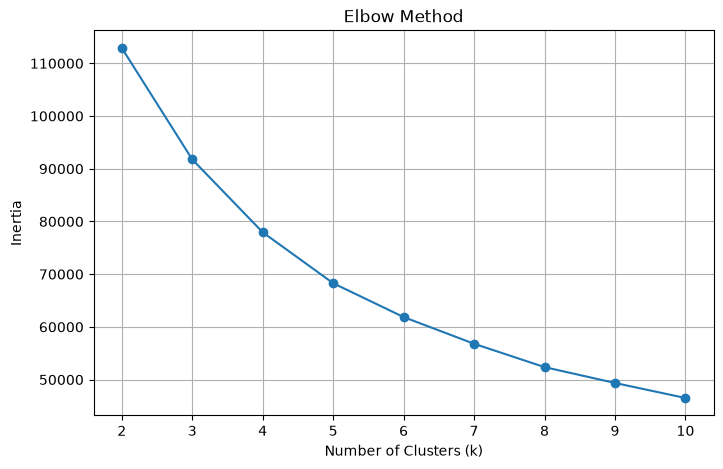

In [67]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

## 15.2 Silhouette Score

In [68]:
# Silhouette score can be expensive on very large datasets.
# Use a fixed sample for efficient and reproducible evaluation.
rng = np.random.RandomState(42)
sample_size = min(5000, len(X_cluster))
sample_idx = rng.choice(len(X_cluster), size=sample_size, replace=False)
X_cluster_sample = X_cluster[sample_idx]

silhouette_results = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster_sample, labels_full[sample_idx])

    silhouette_results.append({
        "k": k,
        "Silhouette Score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df

,k,Silhouette Score
0,2,0.346
1,3,0.292
2,4,0.238
3,5,0.239
4,6,0.234
5,7,0.233
6,8,0.226


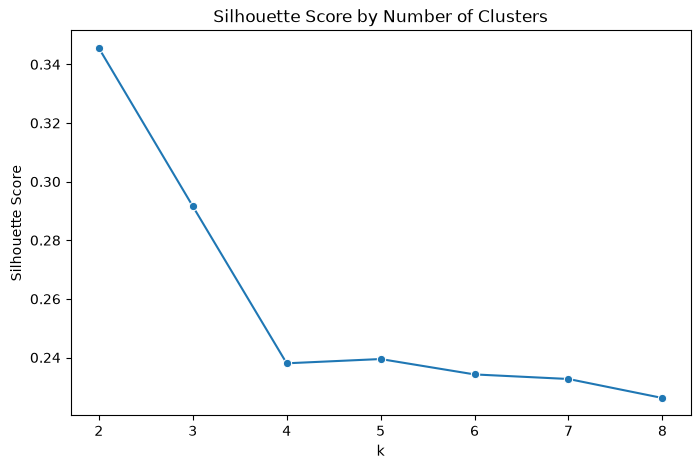

Best k by silhouette score: 2


In [69]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=silhouette_df, x="k", y="Silhouette Score", marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

best_k = int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "k"
    ]
)

print("Best k by silhouette score:", best_k)

## 15.3 Final K-Means Model

In [70]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_cluster)

cluster_df["cluster"] = cluster_labels

print(cluster_df["cluster"].value_counts().sort_index())

cluster
0     9378
1    24282
Name: count, dtype: int64


## 15.4 DBSCAN — Alternative Density-Based Clustering

DBSCAN is included as an alternative unsupervised model. It can identify dense groups and noise points without requiring a fixed number of clusters.

Because DBSCAN can be computationally expensive and sensitive to scale, it is run on a sample.

In [71]:
dbscan_sample_size = min(5000, len(X_cluster))
db_idx = rng.choice(len(X_cluster), size=dbscan_sample_size, replace=False)
X_dbscan = X_cluster[db_idx]

dbscan = DBSCAN(eps=0.8, min_samples=10)
db_labels = dbscan.fit_predict(X_dbscan)

print("DBSCAN label counts:")
print(pd.Series(db_labels).value_counts().sort_index())

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print("Estimated clusters:", n_clusters_db)
print("Noise points:", n_noise)

DBSCAN label counts:
-1     429
 0     645
 1     967
 2     319
 3     640
 4     372
 5     526
 6     513
 7      85
 8      32
 9      73
 10     91
 11     51
 12     68
 13     21
 14     18
 15     22
 16     16
 17     32
 18     21
 19     14
 20     14
 21     10
 22     10
 23     11
Name: count, dtype: int64
Estimated clusters: 24
Noise points: 429


# 16. PCA Visualization

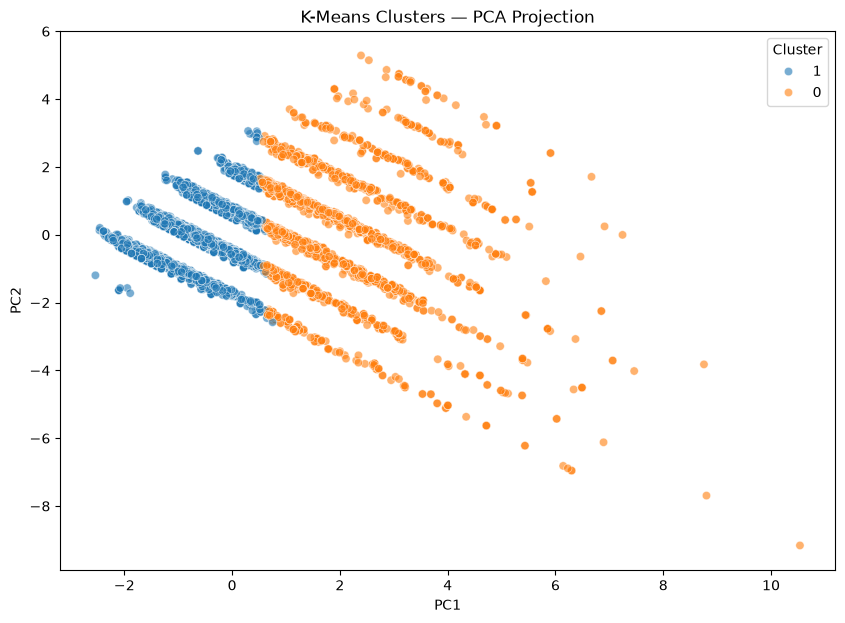

Explained variance ratio: [0.45680094 0.25752436]
Total explained variance: 0.7143


In [72]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels.astype(str)
})

pca_plot = pca_df
if len(pca_plot) > 10000:
    pca_plot = pca_plot.sample(10000, random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.6
)
plt.title("K-Means Clusters — PCA Projection")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

# 17. t-SNE Visualization

t-SNE is used to visualize high-dimensional clustering structure in two dimensions.

Because t-SNE is computationally expensive, a random sample is used.

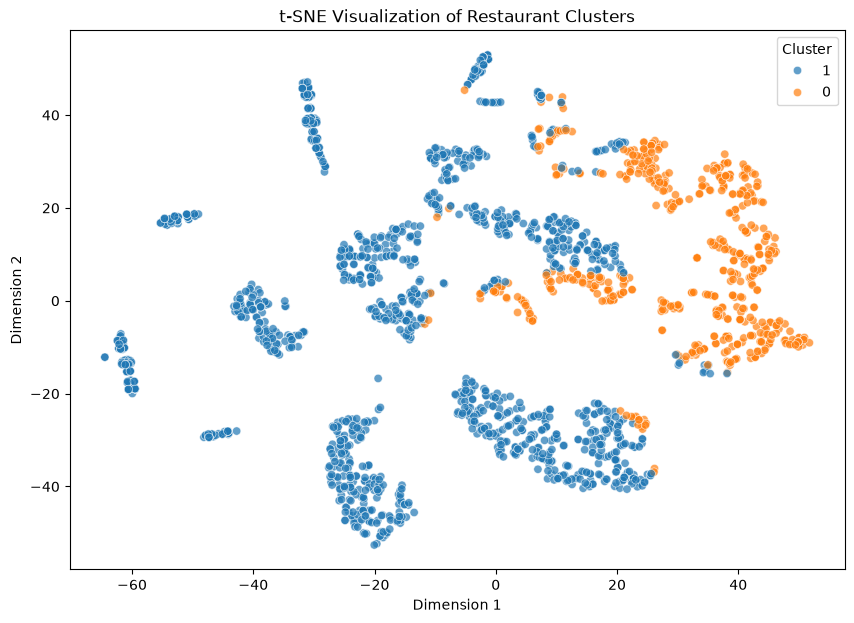

In [73]:
tsne_sample_size = min(2000, len(X_cluster))
tsne_idx = rng.choice(len(X_cluster), size=tsne_sample_size, replace=False)

X_tsne_sample = X_cluster[tsne_idx]
cluster_tsne_labels = cluster_labels[tsne_idx]

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_tsne_sample)

tsne_df = pd.DataFrame({
    "Dimension 1": X_tsne[:, 0],
    "Dimension 2": X_tsne[:, 1],
    "Cluster": cluster_tsne_labels.astype(str)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df,
    x="Dimension 1",
    y="Dimension 2",
    hue="Cluster",
    alpha=0.7
)
plt.title("t-SNE Visualization of Restaurant Clusters")
plt.show()

# 18. Cluster Profiling

In [74]:
cluster_profile_num = cluster_df.groupby("cluster").agg(
    Restaurant_Count=("name", "size"),
    Online_Order_Rate=("online_order_flag", "mean"),
    Table_Booking_Rate=("book_table_flag", "mean"),
    Average_Rating=("rating", "mean"),
    Median_Rating=("rating", "median"),
    Average_Votes=("votes_num", "mean"),
    Median_Votes=("votes_num", "median"),
    Average_Cost=("cost_for_two", "mean"),
    Median_Cost=("cost_for_two", "median"),
    Average_Cuisine_Count=("cuisine_count", "mean")
).round(2)

cluster_profile_num

,Restaurant_Count,Online_Order_Rate,Table_Booking_Rate,Average_Rating,Median_Rating,Average_Votes,Median_Votes,Average_Cost,Median_Cost,Average_Cuisine_Count
cluster,,,,,,,,,,
0,9378,0.660,0.380,3.970,4.000,590.690,291.000,957.740,800.000,3.650
1,24282,0.580,0.010,3.540,3.600,80.460,22.000,385.510,350.000,1.980


In [75]:
def safe_mode(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

cluster_profile_cat = cluster_df.groupby("cluster").agg(
    Most_Common_Location=("location", safe_mode),
    Most_Common_Rest_Type=("rest_type", safe_mode),
    Most_Common_Cuisine=("cuisines", safe_mode),
    Most_Common_Listing_Type=("listed_in(type)", safe_mode)
)

cluster_profile = cluster_profile_num.join(cluster_profile_cat)
cluster_profile

,Restaurant_Count,Online_Order_Rate,Table_Booking_Rate,Average_Rating,Median_Rating,Average_Votes,Median_Votes,Average_Cost,Median_Cost,Average_Cuisine_Count,Most_Common_Location,Most_Common_Rest_Type,Most_Common_Cuisine,Most_Common_Listing_Type
cluster,,,,,,,,,,,,,,
0,9378,0.660,0.380,3.970,4.000,590.690,291.000,957.740,800.000,3.650,Koramangala 5th Block,Casual Dining,Finger Food,Dine-out
1,24282,0.580,0.010,3.540,3.600,80.460,22.000,385.510,350.000,1.980,BTM,Quick Bites,North Indian,Delivery


### Cluster Interpretation Guidance

Use the profile table to give each cluster a business-friendly label, for example:

- **Budget Quick-Service Restaurants**
- **Popular Mid-Range Restaurants**
- **Premium Dine-In Restaurants**
- **Digital-First Delivery Restaurants**

Do not force labels before checking the cluster characteristics.

# 19. Insight Summary

In [76]:
print("===== DATA & KPI INSIGHTS =====")
print(f"Cleaned restaurant listings: {len(df):,}")
print(f"Unique restaurant names: {df['name'].nunique():,}")
print(f"Locations represented: {df['location'].nunique():,}")
print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Median cost for two: ₹{df['cost_for_two'].median():,.0f}")
print(f"Online ordering availability: {df['online_order'].eq('Yes').mean()*100:.2f}%")
print(f"Table booking availability: {df['book_table'].eq('Yes').mean()*100:.2f}%")

print("\n===== MARKET INSIGHTS =====")
print(f"Top location: {df['location'].value_counts().idxmax()} ({df['location'].value_counts().max():,} listings)")
print(f"Top restaurant type: {df['rest_type'].value_counts().idxmax()} ({df['rest_type'].value_counts().max():,} listings)")
print(f"Top cuisine: {cuisine_exploded.value_counts().idxmax()} ({cuisine_exploded.value_counts().max():,} appearances)")
print(f"Most common listing type: {df['listed_in(type)'].value_counts().idxmax()}")

print("\n===== RELATIONSHIP INSIGHTS =====")
print("Average rating by online order:")
print(df.groupby("online_order")["rating"].mean().round(3))
print("\nAverage rating by table booking:")
print(df.groupby("book_table")["rating"].mean().round(3))
print(f"\nRating vs Votes correlation: {df[['rating','votes_num']].corr().iloc[0,1]:.3f}")
print(f"Rating vs Cost correlation: {df[['rating','cost_for_two']].corr().iloc[0,1]:.3f}")

print("\n===== CLASSIFICATION =====")
display(clf_results_df.round(4))
print("Best classification model:", clf_results_df.iloc[0]["Model"])

print("\n===== REGRESSION =====")
display(reg_results_df.round(4))
print("Best regression model:", reg_results_df.iloc[0]["Model"])

print("\n===== CLUSTERING =====")
print("Selected K-Means k:", best_k)
display(cluster_profile)

===== DATA & KPI INSIGHTS =====
Cleaned restaurant listings: 33,660
Unique restaurant names: 8,641
Locations represented: 93
Average rating: 3.68
Median cost for two: ₹400
Online ordering availability: 60.21%
Table booking availability: 11.58%

===== MARKET INSIGHTS =====
Top location: BTM (2,781 listings)
Top restaurant type: Quick Bites (12,691 listings)
Top cuisine: North Indian (13,912 appearances)
Most common listing type: Delivery

===== RELATIONSHIP INSIGHTS =====
Average rating by online order:
online_order
No    3.629
Yes   3.705
Name: rating, dtype: float64

Average rating by table booking:
book_table
No    3.617
Yes   4.078
Name: rating, dtype: float64

Rating vs Votes correlation: 0.399
Rating vs Cost correlation: 0.334

===== CLASSIFICATION =====


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.928,0.950,0.897,0.923,0.972
1,Decision Tree,0.857,0.912,0.775,0.838,0.914
0,Logistic Regression,0.853,0.903,0.776,0.834,0.919


Best classification model: Random Forest

===== REGRESSION =====


,Model,MAE,RMSE,R2 Score
7,Extra Trees,0.065,0.161,0.858
5,Random Forest,0.164,0.246,0.669
4,Decision Tree,0.204,0.298,0.515
6,Gradient Boosting,0.223,0.314,0.460
1,Ridge Regression,0.269,0.349,0.333
0,Linear Regression,0.269,0.349,0.333
3,ElasticNet Regression,0.276,0.355,0.309
2,Lasso Regression,0.278,0.357,0.301


Best regression model: Extra Trees

===== CLUSTERING =====
Selected K-Means k: 2


,Restaurant_Count,Online_Order_Rate,Table_Booking_Rate,Average_Rating,Median_Rating,Average_Votes,Median_Votes,Average_Cost,Median_Cost,Average_Cuisine_Count,Most_Common_Location,Most_Common_Rest_Type,Most_Common_Cuisine,Most_Common_Listing_Type
cluster,,,,,,,,,,,,,,
0,9378,0.660,0.380,3.970,4.000,590.690,291.000,957.740,800.000,3.650,Koramangala 5th Block,Casual Dining,Finger Food,Dine-out
1,24282,0.580,0.010,3.540,3.600,80.460,22.000,385.510,350.000,1.980,BTM,Quick Bites,North Indian,Delivery


# 20. Business Recommendations

## 1. Location Strategy
High restaurant density suggests strong market activity but also greater competition. Evaluate location-level demand, cuisine saturation, price positioning, and nearby competitor quality before opening a new restaurant.

## 2. Online Ordering
If online ordering is common in the data, restaurants targeting convenience-focused customers should maintain reliable ordering, packaging, delivery, and digital menu experiences.

## 3. Table Booking
Table booking is more relevant for dine-in, premium, buffet, pub, and casual-dining formats. Restaurants should adopt booking systems where customer planning and seat utilization matter.

## 4. Cuisine Strategy
Highly represented cuisines show strong demand but usually greater competition. New entrants should differentiate with quality, menu design, price, service, brand positioning, or niche offerings.

## 5. Pricing Strategy
Use price segments rather than a single citywide price. Pricing should reflect target customer, restaurant type, location, cuisine, and service level.

## 6. Customer Engagement
Votes and ratings represent useful customer-engagement signals. Restaurants should encourage authentic reviews and continuously improve food quality, service consistency, and complaint resolution.

## 7. Segment-Specific Strategy
Use restaurant clusters to tailor strategy:
- Budget segment: efficiency, delivery, value.
- Mid-range segment: consistency and repeat visits.
- Premium segment: experience, booking, service.
- High-engagement segment: loyalty and reputation management.

## 8. Model Usage
Classification and regression models should be treated as decision-support tools. Model predictions should complement—not replace—business judgment.

# 21. Conclusion

This project demonstrates a complete Data Science lifecycle:

**Business Understanding → Data Quality → Data Cleaning → EDA → KPI Development → Feature Engineering → Classification → Regression → Cross-Validation → Hyperparameter Tuning → Feature Importance → Clustering → PCA/t-SNE → Business Insights → Recommendations**

The notebook goes beyond simply training models. It focuses on:

- Correct target definition
- Prevention of target leakage
- Appropriate evaluation metrics
- Reproducible preprocessing pipelines
- Model comparison
- Generalization through cross-validation
- Explainability through feature importance
- Unsupervised segmentation
- Business interpretation
